# ⚽ FIFA 20 Player Performance Prediction
### Project Overview
This notebook analyzes the FIFA 20 player dataset to predict player performance metrics using multiple machine learning models. It includes data preprocessing, exploratory data analysis (EDA), model training, evaluation, and final recommendations.

---

# Task 1 — FIFA 20: Complete Data Analysis Report
**Goal:** Clean, explore, and summarize the FIFA 20 players dataset.  
**Outputs:** figures and CSVs saved to `outputs/` for inclusion in the final report.


## 🧹 Data Preprocessing

Preprocessing steps to clean and prepare data for analysis.

---

In [1]:
# Standard imports and settings
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", rc={"figure.dpi": 150})
pd.set_option('display.max_columns', 120)
RANDOM_STATE = 42

# create output folder
os.makedirs("outputs", exist_ok=True)


In [2]:
# Change path if your CSV has a different name
DATA_PATH = "players_20.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Loaded data:", DATA_PATH)
print("Shape:", df.shape)
df.head(5)


Loaded data: players_20.csv
Shape: (18278, 104)


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.0,"#Dribbler, #Distance Shooter, #Crosser, #FK Sp...",RW,10.0,NaN,2004-07-01,2021.0,NaN,NaN,87.0,92.0,92.0,96.0,39.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,"Beat Offside Trap, Argues with Officials, Earl...",88,95,70,92,88,97,93,94,92,96,91,84,93,95,95,86,68,75,68,94,48,40,94,94,75,96,33,37,26,6,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.0,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2018-07-10,2022.0,LS,7.0,90.0,93.0,82.0,89.0,35.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,"Long Throw-in, Selfish, Argues with Officials,...",84,94,89,83,87,89,81,76,77,92,89,91,87,96,71,95,95,85,78,93,63,29,95,82,85,95,28,32,24,7,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,195200000.0,"#Speedster, #Dribbler, #Playmaker , #Crosser,...",CAM,10.0,NaN,2017-08-03,2022.0,LW,10.0,91.0,85.0,87.0,95.0,32.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Injury Free, Selfish, Early C...",87,87,62,87,87,96,88,87,81,95,94,89,96,92,84,80,61,81,49,84,51,36,87,90,90,94,27,26,29,9,9,15,15,11,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,90+3,89+3,82+3,82+3,82+3,89+3,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,GK,Right,3,3,1,Medium/Medium,Normal,Yes,164700000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,89.0,52.0,90.0,"Flair, Acrobatic Clearance",13,11,15,43,13,12,13,14,40,30,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,27,12,18,87,92,78,90,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,"LW, CF",Right,4,4,4,High/Medium,Normal,Yes,184500000.0,"#Speedster, #Dribbler, #Acrobat",LW,7.0,NaN,2019-07-01,

In [3]:
# Basic diagnostics
print("Columns (total):", len(df.columns))
display(df.info())
display(df.describe(include='all').T.head(40))

# Missingness overview
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
display(missing.head(40))
missing.to_csv("outputs/missing_values_by_column.csv")


Columns (total): 104
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sofifa_id,18278.0,NaN,NaN,NaN,219738.864482,27960.200461,768.0,204445.5,226165.0,240795.75,252905.0
player_url,18278,18278,https://sofifa.com/player/158023/lionel-messi/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_name,18278,17354,J. Rodríguez,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
long_name,18278,18218,Liam Kelly,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,18278.0,NaN,NaN,NaN,25.283291,4.656964,16.0,22.0,25.0,29.0,42.0
dob,18278,6142,1992-02-29,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,18278.0,NaN,NaN,NaN,181.362184,6.756961,156.0,177.0,181.0,186.0,205.0
weight_kg,18278.0,NaN,NaN,NaN,75.276343,7.047744,50.0,70.0,75.0,80.0,110.0
nationality,18278,162,England,1667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
club,18278,698,FC Barcelona,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN


loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_speed                16242
gk_diving               16242
gk_handling             16242
gk_reflexes             16242
gk_kicking              16242
gk_positioning          16242
player_traits           10712
lf                       2036
lw                       2036
rs                       2036
physic                   2036
defending                2036
dribbling                2036
passing                  2036
shooting                 2036
st                       2036
ls                       2036
rb                       2036
pace                     2036
rdm                      2036
rwb                      2036
ldm                      2036
lwb                      2036
rm                       2036
rcm                      2036
cm                       2036
lcm                      2036
lm                       2036
ram                      2036
cam       

In [3]:
import math

def money_to_int(x):
    """Convert strings like '€200K', '€1.2M', '200K' to integer euros. Handles numeric input."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(x)
    s = str(x).replace("€","").replace("£","").replace(",","").strip().upper()
    s = s.replace('+','')
    m = re.match(r"^([0-9]*\.?[0-9]+)\s*([KM])?$", s)
    if not m:
        try:
            return int(float(s))
        except:
            return np.nan
    val, suf = m.groups()
    val = float(val)
    if suf == 'K':
        return int(val * 1_000)
    if suf == 'M':
        return int(val * 1_000_000)
    return int(val)

def extract_primary_pos(pos):
    if pd.isna(pos):
        return np.nan
    return str(pos).split(',')[0].strip().upper()


## 📊 Exploratory Data Analysis (EDA)

Visual and statistical exploration of key features and distributions.

---

In [4]:
# Standardize a few common column names if needed
if 'short_name' not in df.columns and 'player_name' in df.columns:
    df = df.rename(columns={'player_name':'short_name'})
if 'player_positions' not in df.columns and 'position' in df.columns:
    df = df.rename(columns={'position':'player_positions'})

# Create standardized columns if missing
if 'short_name' not in df.columns:
    df['short_name'] = df.index.astype(str)

if 'age' not in df.columns:
    print("Warning: 'age' column not found. Please check dataset column names.")

# Primary position
if 'player_positions' in df.columns:
    df['primary_pos'] = df['player_positions'].apply(extract_primary_pos)
else:
    df['primary_pos'] = np.nan

# Convert wage/value columns (if exist)
for col in ['wage','value','release_clause']:
    if col in df.columns:
        df[col + '_num'] = df[col].apply(money_to_int)

# Save snapshot
df.head().to_csv("outputs/df_sample_head.csv", index=False)
print("Basic cleaning done. Columns now include:", list(df.columns)[:40])


Basic cleaning done. Columns now include: ['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking']


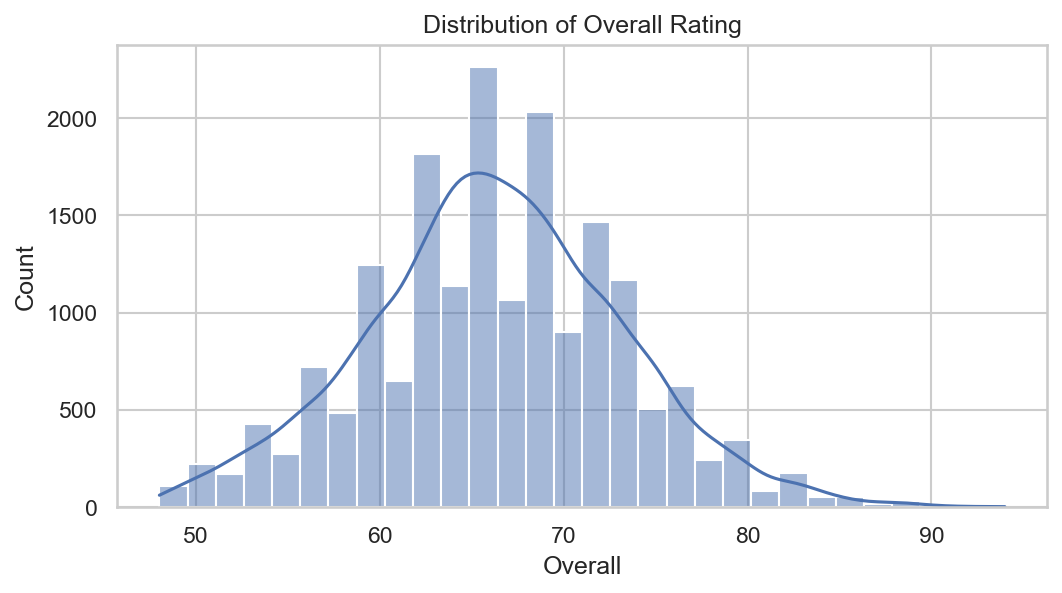

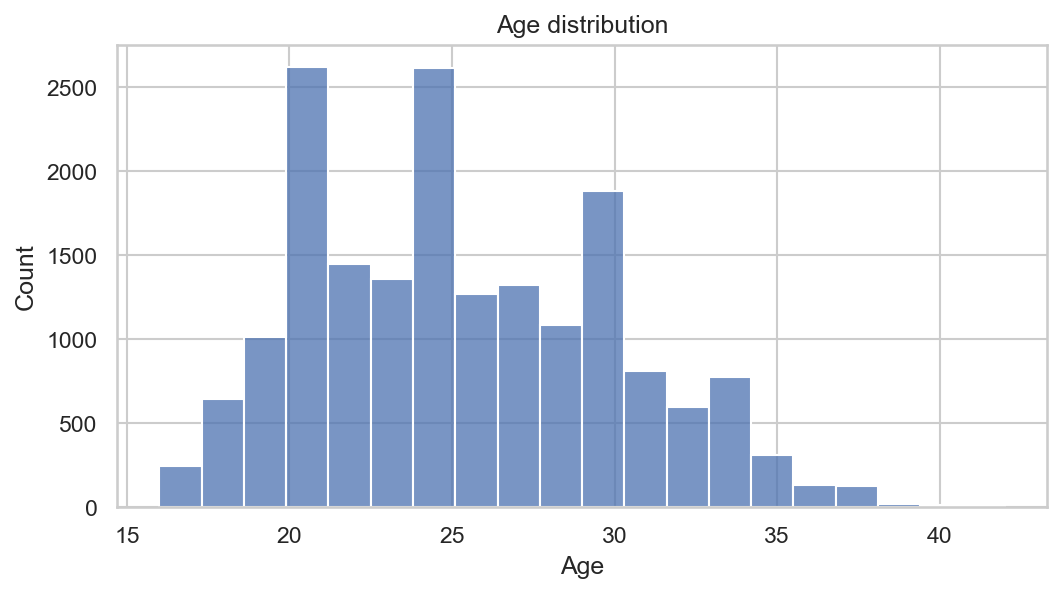

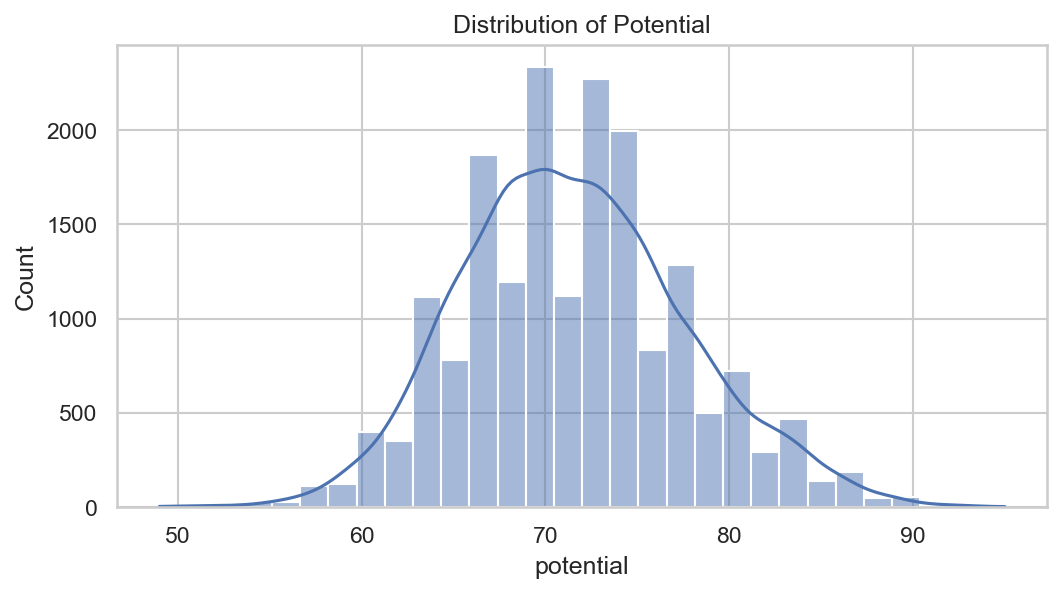

In [73]:
# Find common column names
overall_col = next((c for c in df.columns if c.lower() == 'overall' or 'overall' in c.lower()), None)
potential_col = next((c for c in df.columns if 'potential' in c.lower()), None)
age_col = 'age' if 'age' in df.columns else None

plt.figure(figsize=(8,4))
if overall_col:
    sns.histplot(df[overall_col].dropna(), bins=30, kde=True)
    plt.title("Distribution of Overall Rating")
    plt.xlabel("Overall")
    plt.savefig("outputs/dist_overall.png")
    plt.show()
else:
    print("No overall column found.")

if age_col:
    plt.figure(figsize=(8,4))
    sns.histplot(df[age_col].dropna(), bins=20, kde=False)
    plt.title("Age distribution")
    plt.xlabel("Age")
    plt.savefig("outputs/dist_age.png")
    plt.show()

if potential_col:
    plt.figure(figsize=(8,4))
    sns.histplot(df[potential_col].dropna(), bins=30, kde=True)
    plt.title("Distribution of Potential")
    plt.savefig("outputs/dist_potential.png")
    plt.show()

# Wage/value numeric histograms if present
for col_num in ['wage_num','value_num']:
    if col_num in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col_num].dropna(), bins=40, log_scale=(False, True))
        plt.title(f"Distribution of {col_num} (y-axis log-scale)")
        plt.savefig(f"outputs/dist_{col_num}.png")
        plt.show()


club
FC Barcelona               33
Real Valladolid CF         33
VfL Wolfsburg              33
Crystal Palace             33
Eintracht Frankfurt        33
Hertha BSC                 33
Leicester City             33
AS Monaco                  33
SC Paderborn 07            33
Sevilla FC                 33
Athletic Club de Bilbao    33
Deportivo Alavés           33
Juventus                   33
Udinese                    33
Watford                    33
Name: count, dtype: int64

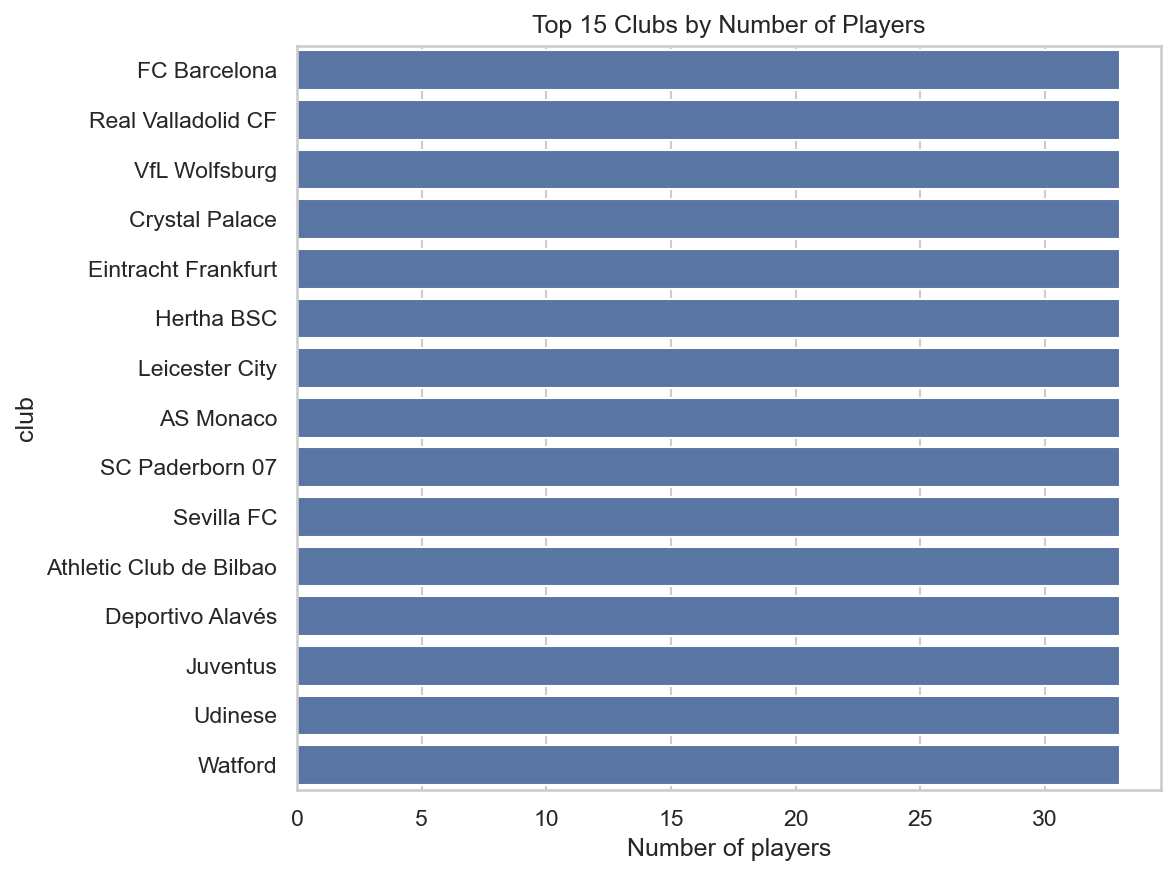

nationality
England                1667
Germany                1216
Spain                  1035
France                  984
Argentina               886
Brazil                  824
Italy                   732
Colombia                591
Japan                   453
Netherlands             416
China PR                373
Chile                   370
Sweden                  358
Norway                  350
Republic of Ireland     348
Name: count, dtype: int64

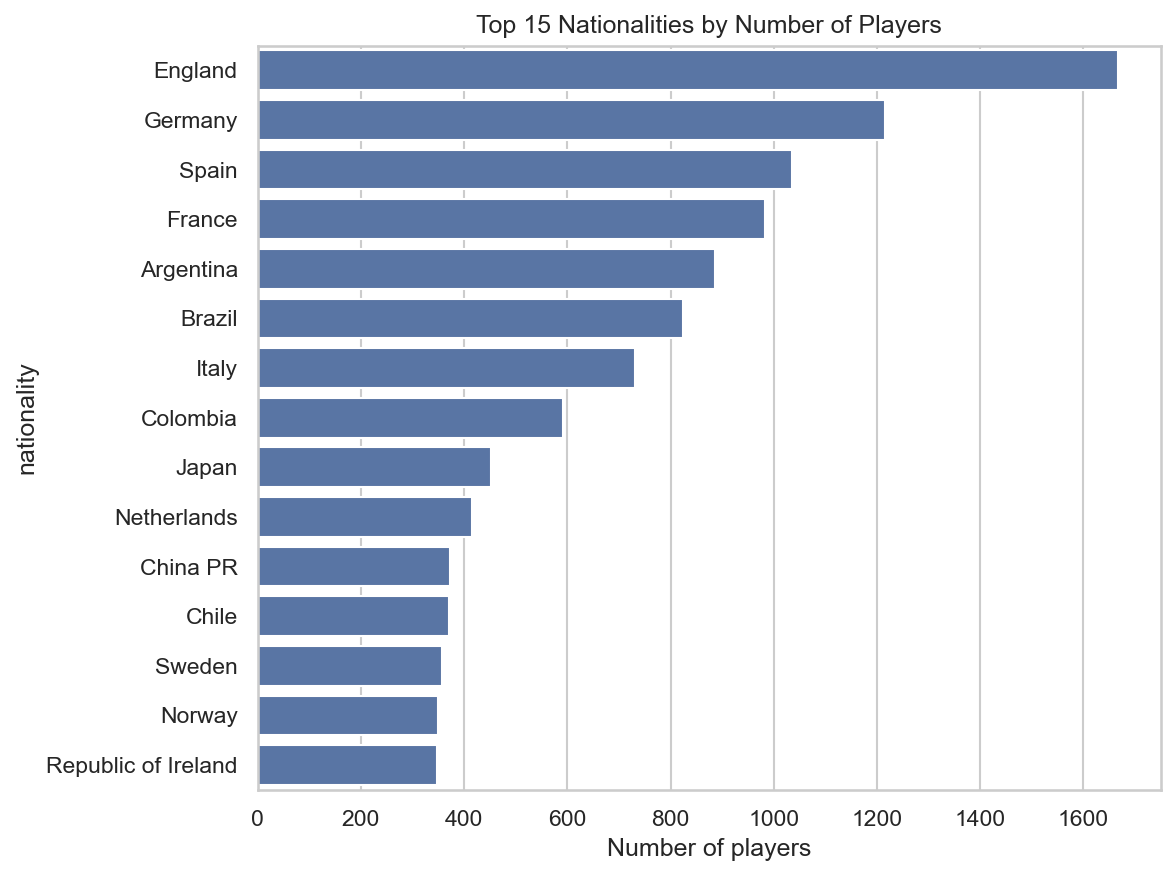

In [5]:
# Top clubs
if 'club' in df.columns:
    top_clubs = df['club'].value_counts().head(15)
    display(top_clubs)
    plt.figure(figsize=(8,6))
    sns.barplot(x=top_clubs.values, y=top_clubs.index)
    plt.title("Top 15 Clubs by Number of Players")
    plt.xlabel("Number of players")
    plt.tight_layout()
    plt.savefig("outputs/top15_clubs.png")
    plt.show()
    top_clubs.to_csv("outputs/top15_clubs.csv")

# Top countries
if 'nationality' in df.columns:
    top_countries = df['nationality'].value_counts().head(15)
    display(top_countries)
    plt.figure(figsize=(8,6))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title("Top 15 Nationalities by Number of Players")
    plt.xlabel("Number of players")
    plt.tight_layout()
    plt.savefig("outputs/top15_countries.png")
    plt.show()
    top_countries.to_csv("outputs/top15_countries.csv")


Skill columns detected: ['attacking_finishing', 'attacking_short_passing', 'defending', 'defending_marking', 'defending_sliding_tackle', 'defending_standing_tackle', 'dribbling', 'mentality_vision', 'movement_acceleration', 'movement_sprint_speed', 'pace', 'passing', 'physic', 'power_stamina', 'power_strength', 'shooting', 'skill_ball_control', 'skill_dribbling', 'skill_long_passing']


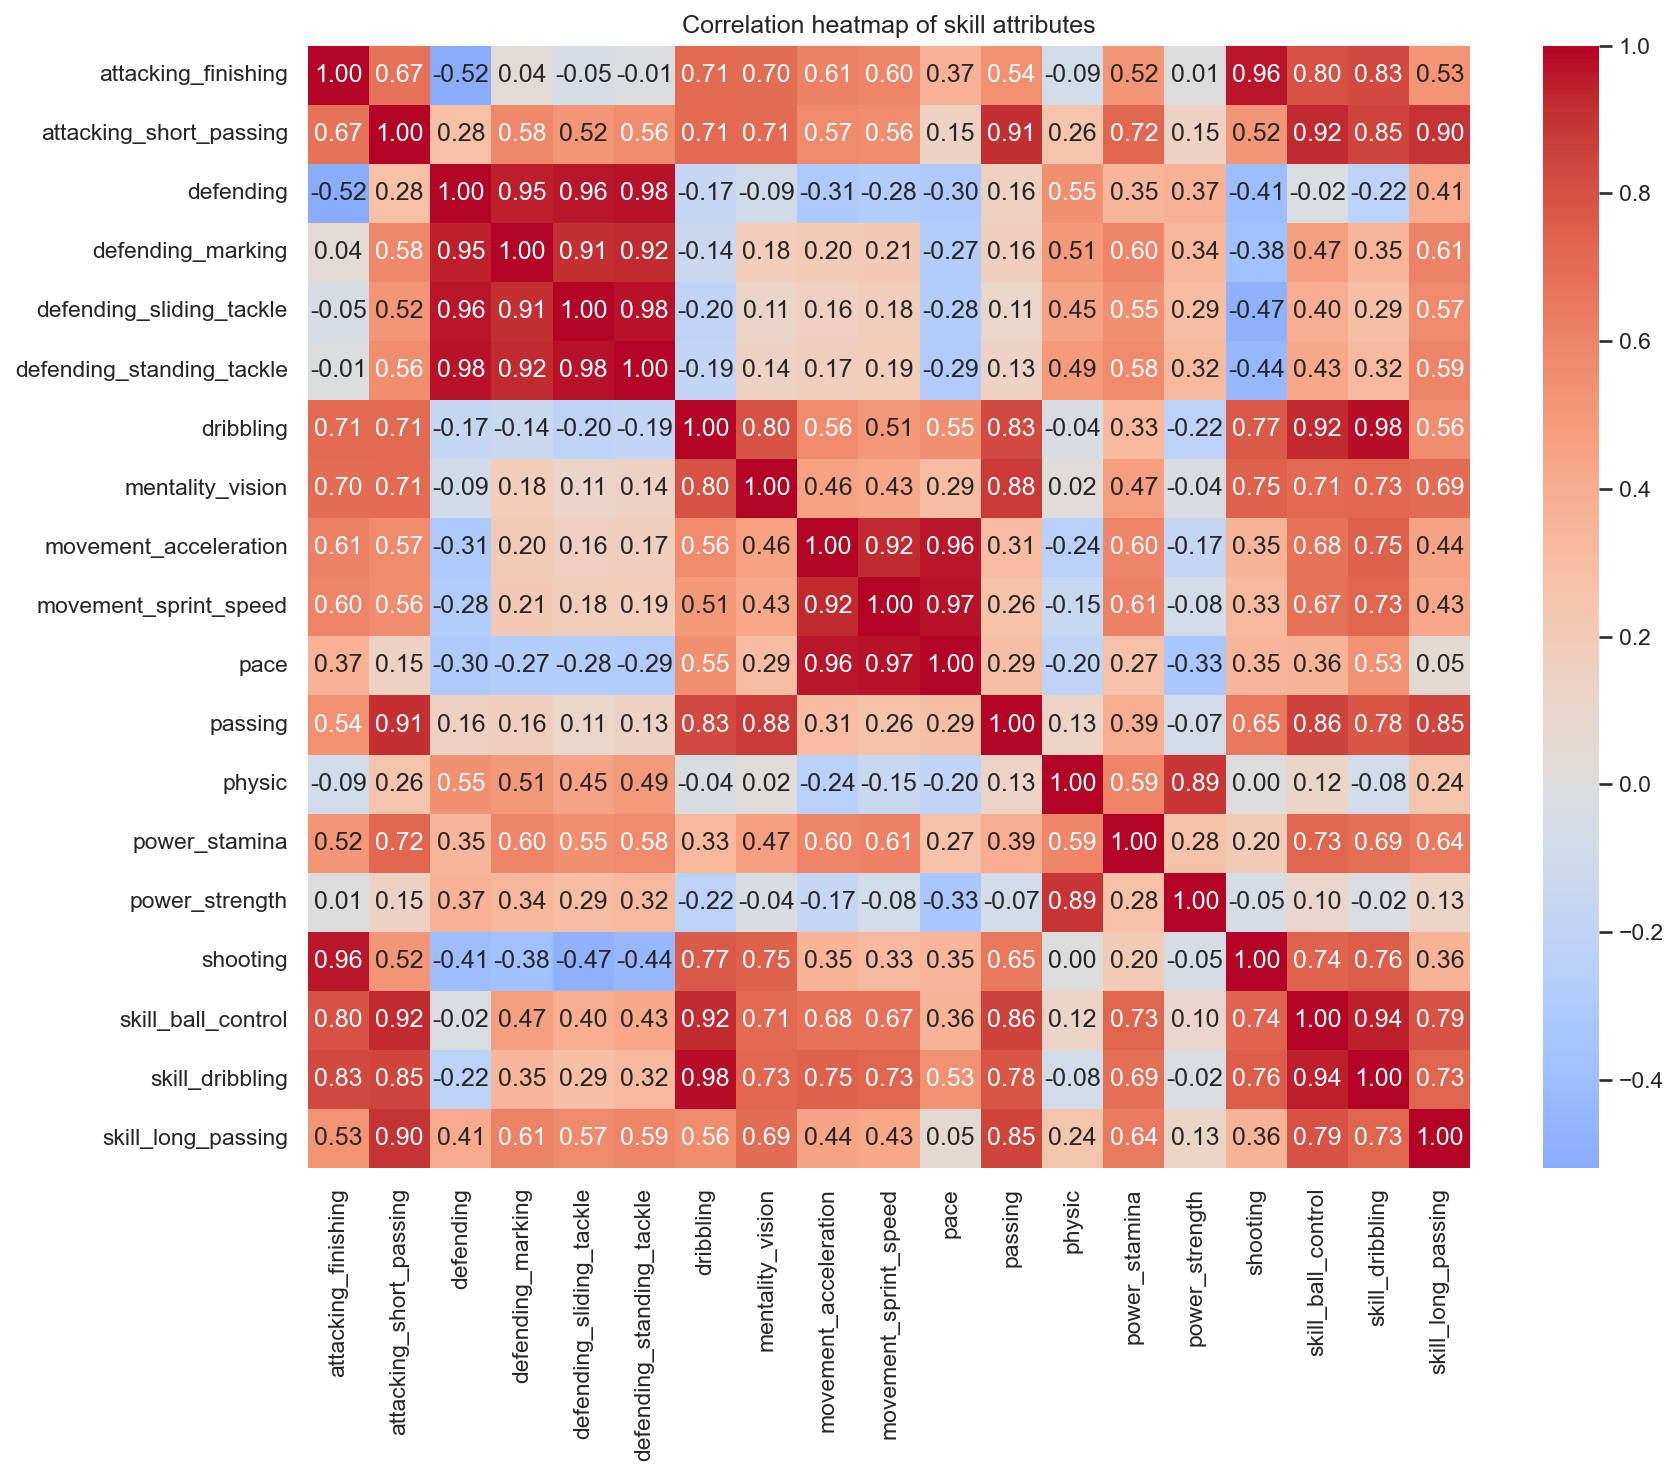

In [6]:
# Choose numeric columns related to skills (auto-detect common skill names)
skill_keywords = ['pace','shoot','pass','drib','defend','physic','control','stamina','strength','vision','accel','sprint','finishing']
skill_cols = [c for c in df.columns if any(k in c.lower() for k in skill_keywords)]
skill_cols = sorted(set(skill_cols))
print("Skill columns detected:", skill_cols[:40])

if len(skill_cols) >= 4:
    corr = df[skill_cols].corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation heatmap of skill attributes")
    plt.tight_layout()
    plt.savefig("outputs/skill_correlation_heatmap.png")
    plt.show()
    corr.to_csv("outputs/skill_correlation.csv")
else:
    print("Not enough detected skill columns to plot correlation heatmap. Detected:", skill_cols)


## 🤖 Model Building

Training different machine learning models on the prepared dataset.

---

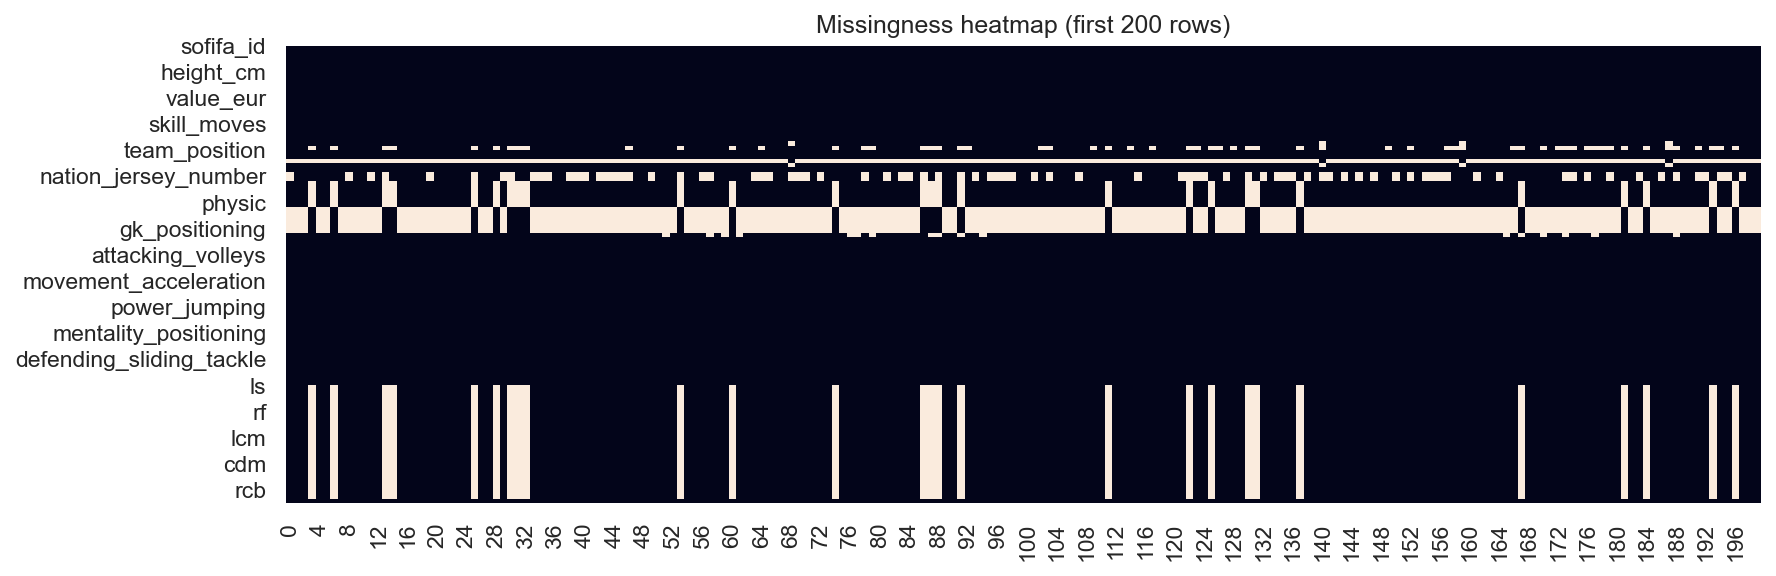

loaned_from                 94.266331
nation_jersey_number        93.839589
nation_position             93.839589
player_tags                 91.798884
gk_positioning              88.860926
gk_speed                    88.860926
gk_reflexes                 88.860926
gk_kicking                  88.860926
gk_handling                 88.860926
gk_diving                   88.860926
player_traits               58.605974
cf                          11.139074
shooting                    11.139074
lf                          11.139074
dribbling                   11.139074
defending                   11.139074
lw                          11.139074
rs                          11.139074
physic                      11.139074
st                          11.139074
ls                          11.139074
passing                     11.139074
pace                        11.139074
rf                          11.139074
ldm                         11.139074
rb                          11.139074
rcb         

In [7]:
# Missingness heatmap (sample first 200 rows for visualization speed)
plt.figure(figsize=(12,4))
sns.heatmap(df.isna().iloc[:200,:].T, cbar=False)
plt.title("Missingness heatmap (first 200 rows)")
plt.tight_layout()
plt.savefig("outputs/missingness_heatmap.png")
plt.show()

# Column missingness percentage
miss_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
display(miss_pct.head(50))
miss_pct.to_csv("outputs/missingness_percentage.csv")


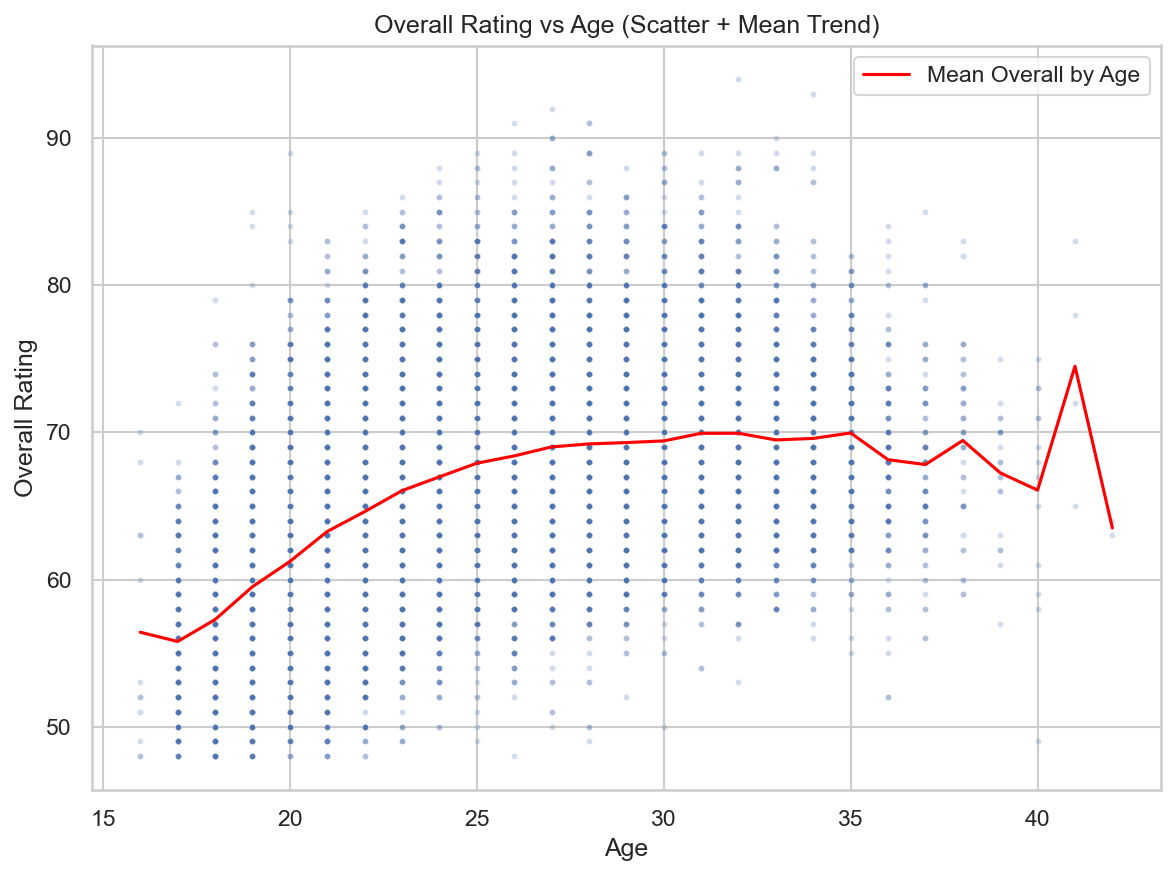

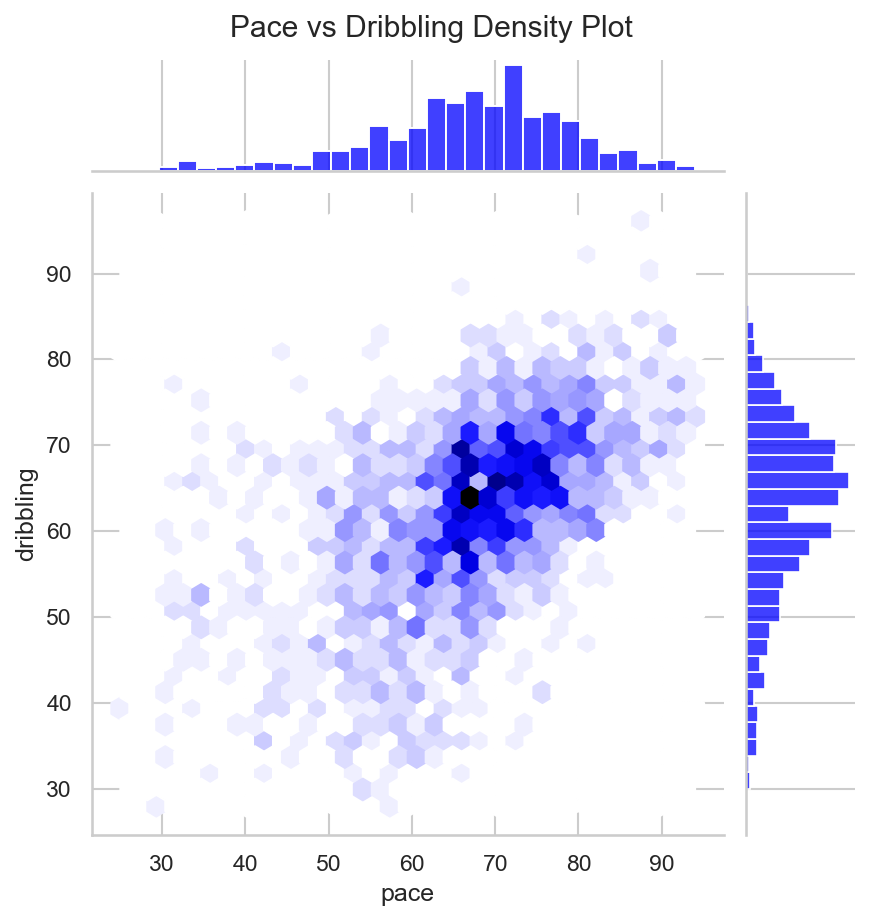

❌ Value or Overall columns not found.


In [9]:
# --- Define key column names first ---
overall_col = 'overall'
age_col = 'age'

# --- Overall vs Age ---
if overall_col in df.columns and age_col in df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x=age_col, y=overall_col, alpha=0.25, s=8)
    # Add mean trend line
    age_means = df.groupby(age_col)[overall_col].mean()
    sns.lineplot(x=age_means.index, y=age_means.values, color='red', label='Mean Overall by Age')
    plt.title("Overall Rating vs Age (Scatter + Mean Trend)")
    plt.xlabel("Age")
    plt.ylabel("Overall Rating")
    plt.tight_layout()
    plt.savefig("outputs/overall_vs_age_scatter.png")
    plt.show()
else:
    print(f"❌ Columns '{overall_col}' or '{age_col}' not found in dataframe.")

# --- Pace vs Dribbling (Skill Relationship) ---
if 'pace' in df.columns and 'dribbling' in df.columns:
    sns.jointplot(
        x='pace',
        y='dribbling',
        data=df.sample(min(2000, len(df))),
        kind='hex',
        color='blue'
    )
    plt.suptitle("Pace vs Dribbling Density Plot", y=1.02)
    plt.savefig("outputs/pace_vs_dribbling_hex.png")
    plt.show()
else:
    print("❌ Columns 'pace' or 'dribbling' not found in dataframe.")

# --- Value vs Overall (Market Value Analysis) ---
val_col = next((c for c in df.columns if 'value' in c.lower() and 'num' in c.lower()), None)

if val_col and overall_col in df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df[overall_col], y=df[val_col], alpha=0.3)
    plt.yscale('log')
    plt.title("Player Market Value (log) vs Overall Rating")
    plt.xlabel("Overall Rating")
    plt.ylabel("Market Value (log scale)")
    plt.tight_layout()
    plt.savefig("outputs/value_vs_overall.png")
    plt.show()
else:
    print("❌ Value or Overall columns not found.")


In [10]:
# By primary_pos
if 'primary_pos' in df.columns:
    pos_summary = df.groupby('primary_pos')[[overall_col]].agg(['count','mean','median']).sort_values(('overall','count'), ascending=False).head(20)
    display(pos_summary)
    pos_summary.to_csv("outputs/pos_summary_overall.csv")

# By age group buckets
if age_col:
    df['age_group'] = pd.cut(df[age_col], bins=[15,20,23,26,29,33,50], labels=['16-20','21-23','24-26','27-29','30-33','34+'])
    agegrp = df.groupby('age_group')[[overall_col]].agg(['count','mean','median'])
    display(agegrp)
    agegrp.to_csv("outputs/age_group_summary.csv")

# By nationality top 10
if 'nationality' in df.columns:
    nat_top10 = df[df['nationality'].isin(df['nationality'].value_counts().head(10).index)]
    nat_summary = nat_top10.groupby('nationality')[[overall_col]].agg(['count','mean','median']).sort_values(('overall','count'), ascending=False)
    display(nat_summary)
    nat_summary.to_csv("outputs/nationality_top10_summary.csv")


overall                  
              count       mean median
primary_pos                          
CB             3162  66.670462   67.0
ST             2582  66.438033   66.0
CM             2193  65.747834   66.0
GK             2036  64.796660   65.0
CDM            1424  67.391152   67.0
RB             1314  66.071537   66.0
LB             1303  65.686109   66.0
CAM            1146  66.899651   67.0
RM             1050  66.065714   66.0
LM             1049  66.459485   67.0
LW              378  66.947090   67.0
RW              369  67.075881   67.0
CF              113  69.132743   68.0
LWB              90  64.822222   64.0
RWB              69  65.695652   65.0

C:\Users\tharu\AppData\Local\Temp\ipykernel_13460\1903249200.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegrp = df.groupby('age_group')[[overall_col]].agg(['count','mean','median'])


overall                  
            count       mean median
age_group                          
16-20        3139  59.449825   59.0
21-23        4179  64.630773   64.0
24-26        3885  67.757529   67.0
27-29        3409  69.164564   69.0
30-33        2762  69.695873   69.0
34+           904  69.248894   69.0

overall                  
              count       mean median
nationality                          
England        1667  63.251950   63.0
Germany        1216  65.939145   66.0
Spain          1035  69.953623   69.0
France          984  67.416667   67.0
Argentina       886  69.118510   70.0
Brazil          824  71.161408   71.0
Italy           732  67.657104   68.0
Colombia        591  65.678511   66.0
Japan           453  63.690949   64.0
Netherlands     416  68.149038   67.0

In [11]:
# Save a cleaned snapshot (no heavy deletions here, just for convenience)
df.to_csv("outputs/players_snapshot.csv", index=False)

# Save list of important columns detected
with open("outputs/columns_list.txt","w",encoding="utf-8") as f:
    for c in df.columns:
        f.write(c + "\n")
print("Saved snapshot and columns list.")


Saved snapshot and columns list.


## 📈 Model Evaluation

Evaluating model performance using metrics such as accuracy, F1-score, ROC-AUC, etc.

---

In [13]:
report_md = f"""
# Quick Analysis Summary (auto-generated)

**Dataset:** {DATA_PATH}  
**Rows:** {len(df)}  **Columns:** {len(df.columns)}

## Missingness
Top columns with missing values saved to `outputs/missing_values_by_column.csv`.

## Top clubs & countries
- Top clubs plot: `outputs/top15_clubs.png`
- Top countries plot: `outputs/top15_countries.png`

## Distributions
- Overall distribution: `outputs/dist_overall.png`
- Age distribution: `outputs/dist_age.png`
- Potential distribution: `outputs/dist_potential.png` (if available)
- Value/wage histograms: `outputs/dist_wage_num.png` (if available)

## Correlations
- Skill correlation heatmap: `outputs/skill_correlation_heatmap.png`

## Suggested next steps
1. Clean high-missing columns (drop or impute based on importance).  
2. Feature engineering: extract preferred foot, work rate split, convert contract expiry to tenure, etc.  
3. Run Task 2 (clustering) using selected skill attributes.  
4. Run Task 3 analysis questions (top countries, overall vs age, wages by position).

"""
print(report_md)
with open("outputs/quick_report_summary.md", "w", encoding="utf-8") as f:
    f.write(report_md)
print("Auto-generated report saved as outputs/quick_report_summary.md")



# Quick Analysis Summary (auto-generated)

**Dataset:** players_20.csv  
**Rows:** 18278  **Columns:** 106

## Missingness
Top columns with missing values saved to `outputs/missing_values_by_column.csv`.

## Top clubs & countries
- Top clubs plot: `outputs/top15_clubs.png`
- Top countries plot: `outputs/top15_countries.png`

## Distributions
- Overall distribution: `outputs/dist_overall.png`
- Age distribution: `outputs/dist_age.png`
- Potential distribution: `outputs/dist_potential.png` (if available)
- Value/wage histograms: `outputs/dist_wage_num.png` (if available)

## Correlations
- Skill correlation heatmap: `outputs/skill_correlation_heatmap.png`

## Suggested next steps
1. Clean high-missing columns (drop or impute based on importance).  
2. Feature engineering: extract preferred foot, work rate split, convert contract expiry to tenure, etc.  
3. Run Task 2 (clustering) using selected skill attributes.  
4. Run Task 3 analysis questions (top countries, overall vs age, wages by

## Final notes & how to include figures in your report

- All figures and CSV summaries are in the `outputs/` folder.
- In your report, include each figure with a one-line caption and a one-paragraph interpretation.
- Mention limitations: dataset biases, missing values, and differences in column names across versions of the dataset.
- Next recommended steps: task2 (clustering), task3 (answer specific Qs), and a short model/visualization dashboard.


# Task 2 — Clustering Football Players
**Goal:** Cluster FIFA 20 players based on their skill attributes using KMeans.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid", rc={"figure.dpi":150})


In [27]:
# Candidate numeric skill columns (adjust based on your dataset)
candidate_cols = [
    'pace', 'shooting', 'passing', 'dribbling', 
    'defending', 'physical', 'crossing', 'finishing', 
    'short_passing', 'volleys', 'strength', 'agility'
]

# Keep only columns that actually exist in your dataframe
numeric_cols = [c for c in candidate_cols if c in df.columns]
print(" Columns used for clustering:", numeric_cols)


 Columns used for clustering: ['pace', 'shooting', 'passing', 'dribbling', 'defending']


In [28]:
# Keep only rows with complete data
df_clust = df[numeric_cols].dropna()
print("Number of players used for clustering:", len(df_clust))

# Scale the numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
player_scaled = scaler.fit_transform(df_clust)

print("Scaled feature matrix shape:", player_scaled.shape)


Number of players used for clustering: 16242
Scaled feature matrix shape: (16242, 5)


In [31]:
from sklearn.cluster import KMeans
import numpy as np

# Suppose df_clust is the filtered DataFrame used for scaling
df_clust = df[numeric_cols].dropna()  # example

# Scale the data (your scaled array)
player_scaled = df_clust.values  # or use StandardScaler

# Fit KMeans
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(player_scaled)

# Add clusters only to the filtered DataFrame
df.loc[df_clust.index, 'cluster'] = clusters

# Show cluster counts
print("Cluster counts:")
print(df['cluster'].value_counts(dropna=False))


Cluster counts:
cluster
3.0    4218
2.0    3298
0.0    3226
4.0    2930
1.0    2570
NaN    2036
Name: count, dtype: int64


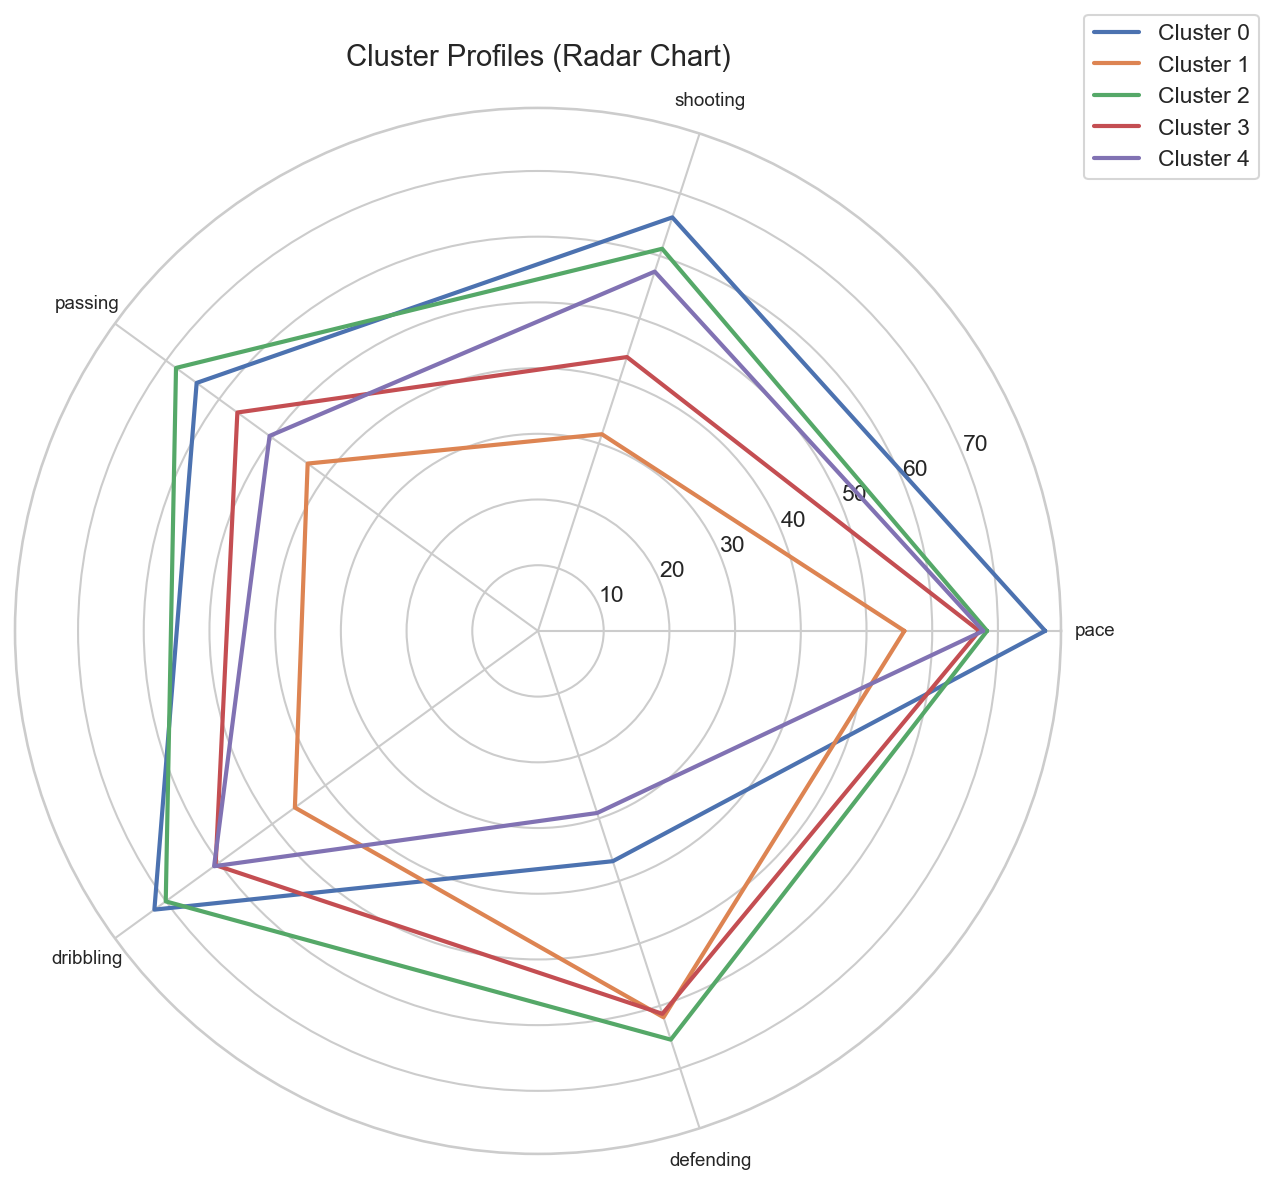

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from sklearn.cluster import KMeans

# Example: your dataframe `df` should already be loaded
# df = pd.read_csv('players_20.csv')  # your dataset path

# Define numeric columns for clustering
numeric_cols = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physical']

# Keep only existing columns
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Drop rows with NaN in numeric columns (for clustering)
df_clust = df[numeric_cols].dropna()

# Number of clusters
k = 5

# Fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(df_clust)

# Assign cluster labels back to the original DataFrame
df.loc[df_clust.index, 'cluster'] = clusters

# Compute cluster means
cluster_means = df_clust.copy()
cluster_means['cluster'] = clusters
cluster_means = cluster_means.groupby('cluster')[numeric_cols].mean()

# Number of categories
N = len(numeric_cols)

# Prepare angles for radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the circle

# Plot radar chart
plt.figure(figsize=(10,8))
for i in range(k):
    values = cluster_means.loc[i].values.flatten().tolist()
    values += values[:1]  # close the circle
    plt.polar(angles, values, linewidth=2, label=f'Cluster {i}')

# Labels and title
plt.xticks(angles[:-1], numeric_cols, fontsize=9)
plt.title("Cluster Profiles (Radar Chart)", size=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()


C:\Users\tharu\AppData\Local\Temp\ipykernel_13460\3413487952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df, palette='viridis', dodge=False)


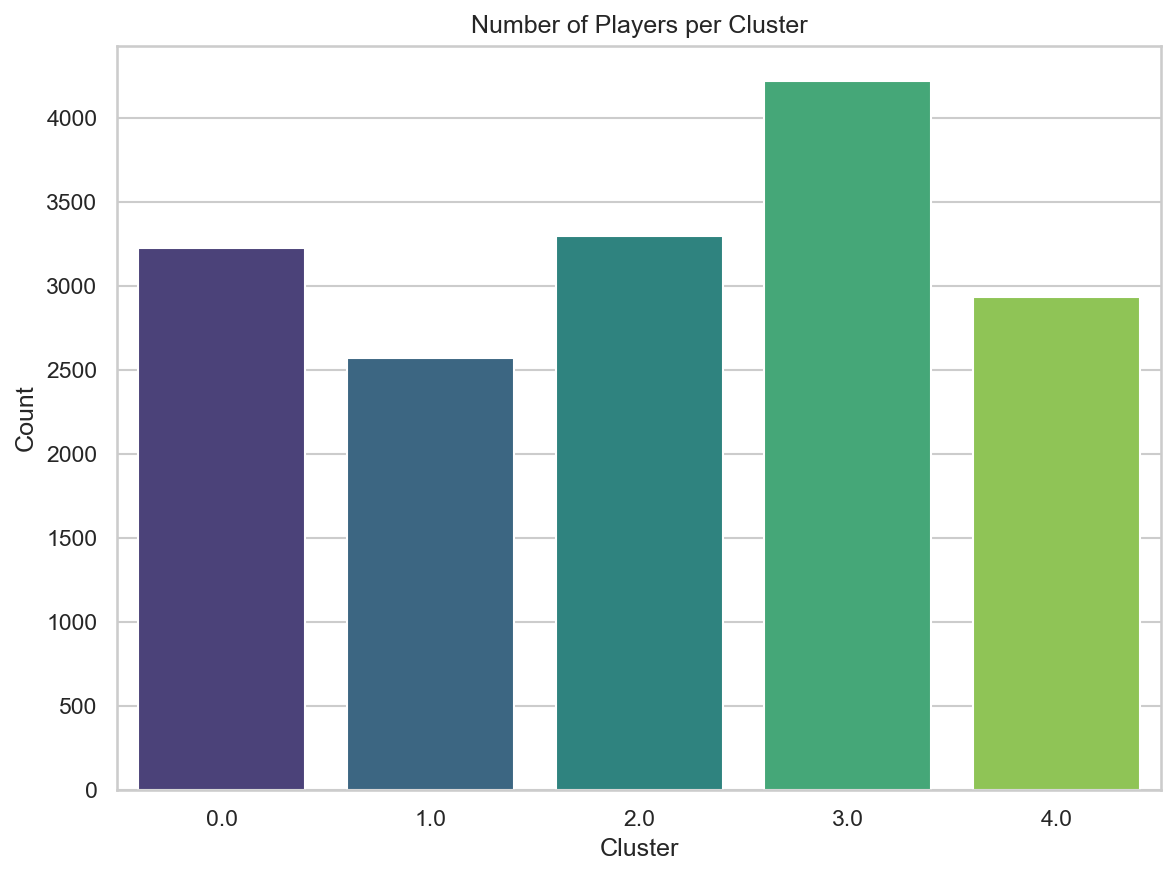

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='cluster', data=df, palette='viridis', dodge=False)
plt.title("Number of Players per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [35]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import kruskal, mannwhitneyu

sns.set(style="whitegrid")
os.makedirs("outputs", exist_ok=True)


In [36]:
DATA_PATH = "players_20.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
df.head()


Shape: (18278, 104)


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.0,"#Dribbler, #Distance Shooter, #Crosser, #FK Sp...",RW,10.0,NaN,2004-07-01,2021.0,NaN,NaN,87.0,92.0,92.0,96.0,39.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,"Beat Offside Trap, Argues with Officials, Earl...",88,95,70,92,88,97,93,94,92,96,91,84,93,95,95,86,68,75,68,94,48,40,94,94,75,96,33,37,26,6,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.0,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2018-07-10,2022.0,LS,7.0,90.0,93.0,82.0,89.0,35.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,"Long Throw-in, Selfish, Argues with Officials,...",84,94,89,83,87,89,81,76,77,92,89,91,87,96,71,95,95,85,78,93,63,29,95,82,85,95,28,32,24,7,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,195200000.0,"#Speedster, #Dribbler, #Playmaker , #Crosser,...",CAM,10.0,NaN,2017-08-03,2022.0,LW,10.0,91.0,85.0,87.0,95.0,32.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Injury Free, Selfish, Early C...",87,87,62,87,87,96,88,87,81,95,94,89,96,92,84,80,61,81,49,84,51,36,87,90,90,94,27,26,29,9,9,15,15,11,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,90+3,89+3,82+3,82+3,82+3,89+3,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,GK,Right,3,3,1,Medium/Medium,Normal,Yes,164700000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,89.0,52.0,90.0,"Flair, Acrobatic Clearance",13,11,15,43,13,12,13,14,40,30,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,27,12,18,87,92,78,90,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,"LW, CF",Right,4,4,4,High/Medium,Normal,Yes,184500000.0,"#Speedster, #Dribbler, #Acrobat",LW,7.0,NaN,2019-07-01,

In [37]:
# Standardize common column names
if 'short_name' not in df.columns and 'player_name' in df.columns:
    df = df.rename(columns={'player_name':'short_name'})
if 'player_positions' not in df.columns and 'position' in df.columns:
    df = df.rename(columns={'position':'player_positions'})

# Age and overall
if 'age' not in df.columns:
    print("Warning: 'age' column not found")
overall_col = next((c for c in df.columns if 'overall' in c.lower()), None)


nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


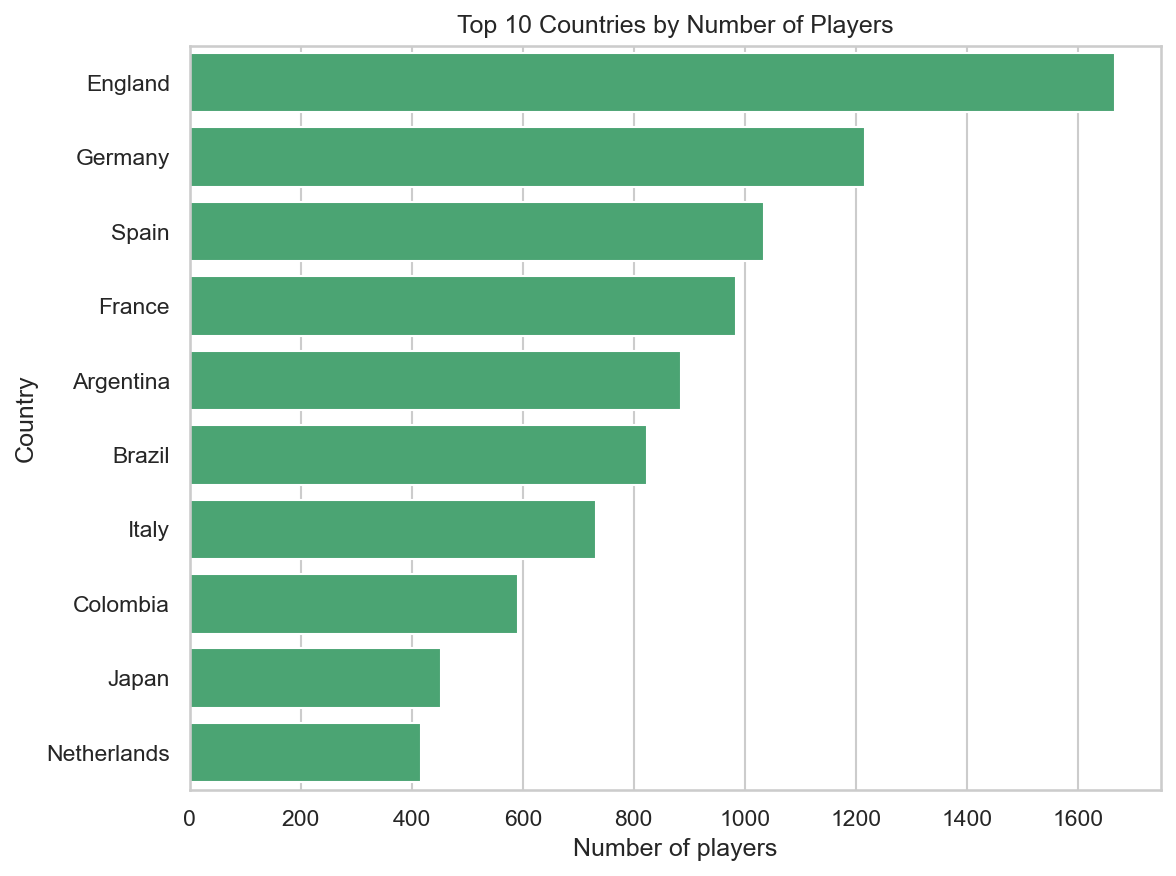

In [38]:
if 'nationality' in df.columns:
    top10 = df['nationality'].value_counts().head(10)
    print(top10)

    # Future-proof barplot
    plt.figure(figsize=(8,6))
    sns.barplot(x=top10.values, y=top10.index, color='mediumseagreen')  # use 'color' instead of 'palette'
    plt.title("Top 10 Countries by Number of Players")
    plt.xlabel("Number of players")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.savefig("outputs/top10_countries.png")
    plt.show()

    # Save CSV
    top10.to_csv("outputs/top10_countries.csv")


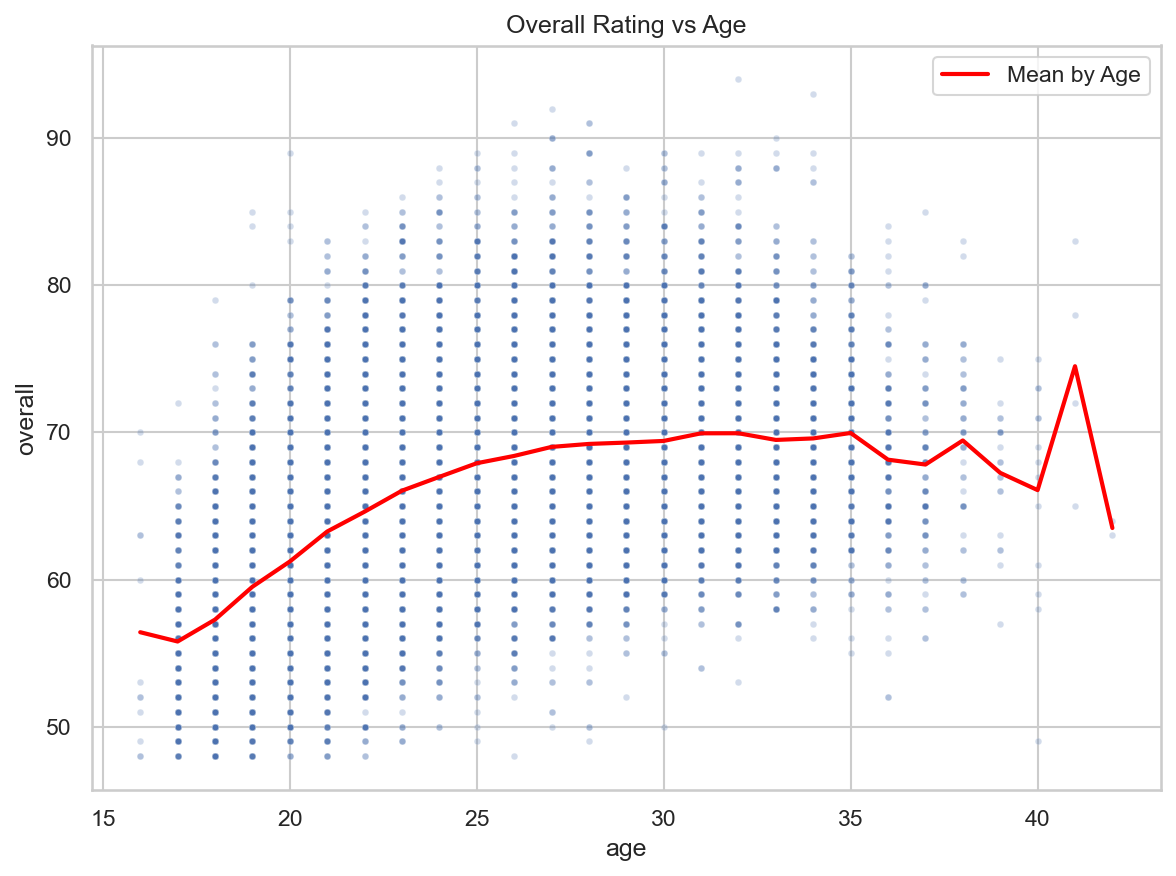

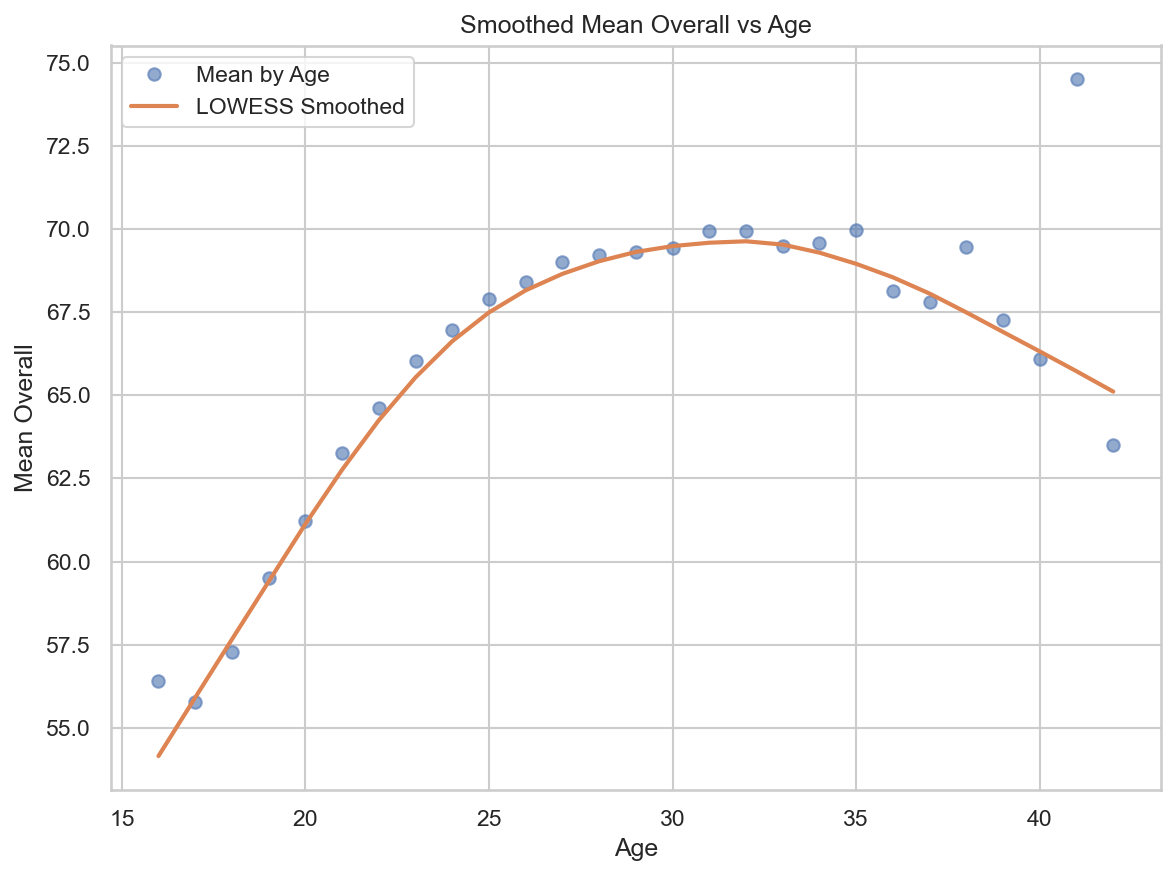

Peak mean overall ≈ 69.63 at age ≈ 32
Heuristic 'stop improving' age: 32


In [39]:
df_age = df[['age', overall_col]].dropna()
df_age.columns = ['age','overall']

# Scatter + mean by age
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_age, x='age', y='overall', alpha=0.25, s=10)
mean_by_age = df_age.groupby('age')['overall'].mean()
plt.plot(mean_by_age.index, mean_by_age.values, color='red', linewidth=2, label='Mean by Age')
plt.title("Overall Rating vs Age")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/overall_vs_age_scatter.png")
plt.show()

# LOWESS smoothing
ages = mean_by_age.index.values
vals = mean_by_age.values
sm = lowess(vals, ages, frac=0.4)
ages_sm, vals_sm = sm[:,0], sm[:,1]

plt.figure(figsize=(8,6))
plt.plot(ages, vals, 'o', alpha=0.6, label='Mean by Age')
plt.plot(ages_sm, vals_sm, '-', linewidth=2, label='LOWESS Smoothed')
plt.xlabel("Age")
plt.ylabel("Mean Overall")
plt.title("Smoothed Mean Overall vs Age")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/overall_vs_age_smoothed.png")
plt.show()

# Peak age
peak_idx = int(np.argmax(vals_sm))
peak_age = int(round(ages_sm[peak_idx]))
peak_value = vals_sm[peak_idx]
print(f"Peak mean overall ≈ {peak_value:.2f} at age ≈ {peak_age}")

# Heuristic: stop improving age (3 consecutive declines)
stop_age = None
N = 3
for i in range(peak_idx, len(vals_sm)-N):
    dec = all(vals_sm[i+j] < vals_sm[i+j-1] for j in range(1, N+1))
    if dec:
        stop_age = int(round(ages_sm[i]))
        break
print("Heuristic 'stop improving' age:", stop_age)


In [40]:
def money_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int,float)):
        return int(x)
    s = str(x).replace("€","").replace(",","").strip().upper().replace("+","")
    match = re.match(r"([0-9]*\.?[0-9]+)([KM])?", s)
    if not match:
        return np.nan
    val, suf = match.groups()
    val = float(val)
    if suf == 'K':
        return int(val*1_000)
    if suf == 'M':
        return int(val*1_000_000)
    return int(val)

wage_col = next((c for c in df.columns if 'wage' in c.lower()), None)
df['wage_num'] = df[wage_col].apply(money_to_int) if wage_col else np.nan


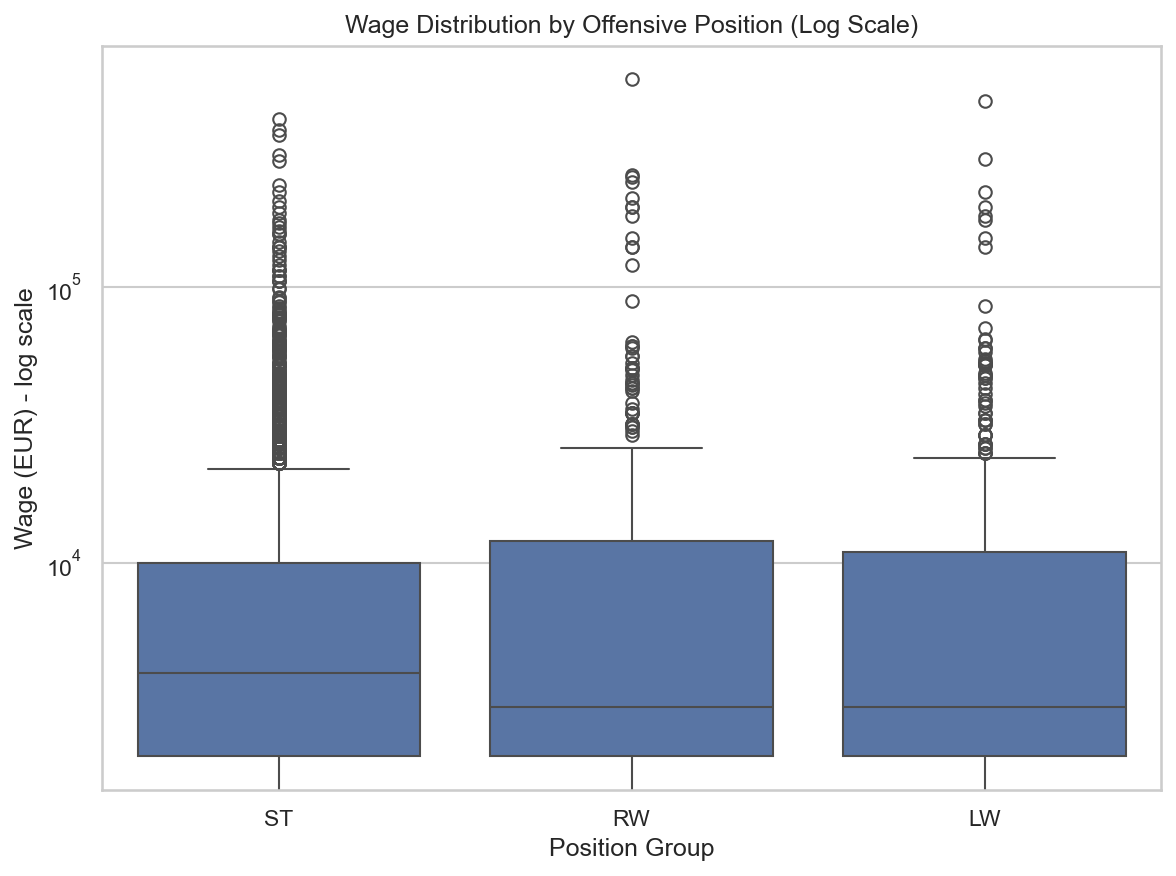

           count          mean  median           std
pos_group                                           
LW           378  14037.037037  3000.0  37428.888596
RW           369  15848.238482  3000.0  44634.612634
ST          2695  10928.014842  4000.0  24287.898579
Kruskal-Wallis H=0.2894, p=0.865284
LW vs RW: p_adj=1.000000
LW vs ST: p_adj=1.000000
RW vs ST: p_adj=1.000000


In [41]:
# Map primary positions
def get_primary_pos(pos):
    if pd.isna(pos): return np.nan
    token = str(pos).split(',')[0].strip().upper()
    if token in ['ST','CF','FW']: return 'ST'
    if token == 'RW': return 'RW'
    if token == 'LW': return 'LW'
    return token

df['pos_group'] = df['player_positions'].apply(get_primary_pos)

# Filter offensive players
df_off = df[df['pos_group'].isin(['ST','RW','LW'])].dropna(subset=['wage_num'])

# Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='pos_group', y='wage_num', data=df_off, order=['ST','RW','LW'])
plt.yscale('log')
plt.title("Wage Distribution by Offensive Position (Log Scale)")
plt.xlabel("Position Group")
plt.ylabel("Wage (EUR) - log scale")
plt.tight_layout()
plt.savefig("outputs/wage_boxplot_offensive_pos.png")
plt.show()

# Summary stats
summary = df_off.groupby('pos_group')['wage_num'].agg(['count','mean','median','std'])
print(summary)

# Kruskal-Wallis test
groups = [g['wage_num'].values for _, g in df_off.groupby('pos_group')]
kw_stat, kw_p = kruskal(*groups)
print(f"Kruskal-Wallis H={kw_stat:.4f}, p={kw_p:.6f}")

# Pairwise Mann-Whitney U with Bonferroni correction
pos_unique = sorted(df_off['pos_group'].unique())
m = len(pos_unique)*(len(pos_unique)-1)//2
for i in range(len(pos_unique)):
    for j in range(i+1, len(pos_unique)):
        a, b = pos_unique[i], pos_unique[j]
        ga = df_off[df_off['pos_group']==a]['wage_num'].values
        gb = df_off[df_off['pos_group']==b]['wage_num'].values
        stat, p = mannwhitneyu(ga, gb)
        p_adj = min(p*m,1.0)
        print(f"{a} vs {b}: p_adj={p_adj:.6f}")


## 🏁 Conclusion

Summarizing insights and identifying the best model for production deployment.

---